In [37]:
'''
Author: Yaseer
Dijkstra's Algorithm with Full Relaxation History
This script builds a sample directed graph and runs Dijkstra’s SSSP algorithm
while printing every relaxation event, visited-node update, and final results.
'''

import sys
from collections import defaultdict
import heapq


# ===========================================================
#   Graph Class
#   - Stores nodes, edges, and weights
#   - Supports both Dijkstra and (optionally) MST initialization
# ===========================================================
class Graph:
    def __init__(self):
        self.nodes = set()                  # Set of vertices
        self.edges = defaultdict(list)      # Adjacency list: u -> [v1, v2, ...]
        self.distances = {}                 # Edge weights: (u, v) -> weight

    def add_node(self, value):
        """Add a new vertex to the graph."""
        self.nodes.add(value)

    def add_edge(self, from_node, to_node, distance):
        """Add a directed edge with a positive weight."""
        self.edges[from_node].append(to_node)
        self.distances[(from_node, to_node)] = distance

    def initializeDistances(self):
        """
        (Used only in MST versions)
        Initializes all distances to MAX except root-distance entries.
        Not used in this Dijkstra implementation.
        """
        for i in self.nodes:
            for j in self.nodes:
                self.distances[(i, j)] = sys.maxsize
        # Distance to 'empty parent' is treated as 0
        for i in self.nodes:
            self.distances[(i, "")] = 0


# ===========================================================
#   Dijkstra with full relaxation history
# ===========================================================
def dijkstra_with_history(graph, start):
    """
    Dijkstra’s algorithm that prints ALL relaxation steps,
    visited-node updates, and final shortest-path results.

    Parameters:
        graph: Graph object
        start: starting node label

    Returns:
        dist: shortest distances from start
        prev: predecessor dictionary for path reconstruction
    """

    # Initialize distances to INF; start node gets 0
    dist = {node: float("inf") for node in graph.nodes}
    prev = {node: None for node in graph.nodes}
    dist[start] = 0

    visited = set()
    pq = [(0, start)]   # Min-heap of (distance, node)

    print("=== Dijkstra's Algorithm (with relaxation history) ===")
    print(f"Start node: {start}")
    print(f"Initial distances: {dist}\n")

    # ---- Main loop ----
    while pq:
        current_dist, u = heapq.heappop(pq)

        # Skip if we've already processed this node
        if u in visited:
            continue

        # Mark node as visited
        visited.add(u)
        print(f"Node({u}) with Weight:{current_dist} is added to the 'Visited' {visited}")

        # If no outgoing edges, report and move on
        if not graph.edges[u]:
            print(f"No unvisited outgoing edges from the node, {u}\n")
            continue

        any_relaxed = False  # Tracks whether any edge was relaxed

        # ---- Relax edges from u to neighbors ----
        for v in graph.edges[u]:
            weight = graph.distances[(u, v)]
            old_dist = dist[v]
            new_dist = dist[u] + weight

            if new_dist < old_dist:
                # Relaxation successful
                any_relaxed = True
                dist[v] = new_dist
                prev[v] = u

                print(
                    f"Relaxed: vertex[{v}]: OLD: {old_dist}, "
                    f"NEW: {new_dist}, Paths: {{'{v}': '{u}'}}"
                )
            else:
                print(
                    f"No relaxation for edge ({u} -> {v}), "
                    f"current best for {v} is {old_dist}, "
                    f"candidate is {new_dist}"
                )

        # If no neighbors were improved
        if not any_relaxed:
            print(f"No edge relaxation is needed for node, {u}")

        print()  # add blank line for readability

        # Push all neighbors into PQ (even if not relaxed)
        for v in graph.edges[u]:
            heapq.heappush(pq, (dist[v], v))

    # ---- Final results ----
    print("=== Final Results ===")
    print("Distances from start:")
    for node in sorted(graph.nodes):
        print(f"{start} -> {node}: {dist[node]}")

    print("\nPredecessors (shortest-path tree):")
    for node in sorted(graph.nodes):
        print(f"prev[{node}] = {prev[node]}")

    return dist, prev


# ===========================================================
#   Build a sample 8-node graph
# ===========================================================
def build_sample_graph():
    """
    Constructs a sample graph used for testing Dijkstra with history.
    Matches the example structure used in many lectures
    (A–H with directed weighted edges).
    """
    g = Graph()

    # Add nodes A through H
    for node in ["A", "B", "C", "D", "E", "F", "G", "H"]:
        g.add_node(node)

    # Add edges with weights
    g.add_edge("A", "B", 3)
    g.add_edge("A", "C", 2)
    g.add_edge("B", "C", 1)
    g.add_edge("B", "D", 4)
    g.add_edge("C", "D", 2)
    g.add_edge("C", "E", 5)
    g.add_edge("D", "E", 1)
    g.add_edge("D", "F", 3)
    g.add_edge("E", "F", 1)
    g.add_edge("E", "G", 2)
    g.add_edge("F", "H", 4)
    g.add_edge("G", "H", 1)

    return g


# ===========================================================
#   Main Driver
# ===========================================================
if __name__ == "__main__":
    graph = build_sample_graph()
    # Run Dijkstra starting at A
    dijkstra_with_history(graph, start="A")


=== Dijkstra's Algorithm (with relaxation history) ===
Start node: A
Initial distances: {'E': inf, 'D': inf, 'C': inf, 'G': inf, 'B': inf, 'A': 0, 'H': inf, 'F': inf}

Node(A) with Weight:0 is added to the 'Visited' {'A'}
Relaxed: vertex[B]: OLD: inf, NEW: 3, Paths: {'B': 'A'}
Relaxed: vertex[C]: OLD: inf, NEW: 2, Paths: {'C': 'A'}

Node(C) with Weight:2 is added to the 'Visited' {'C', 'A'}
Relaxed: vertex[D]: OLD: inf, NEW: 4, Paths: {'D': 'C'}
Relaxed: vertex[E]: OLD: inf, NEW: 7, Paths: {'E': 'C'}

Node(B) with Weight:3 is added to the 'Visited' {'C', 'B', 'A'}
No relaxation for edge (B -> C), current best for C is 2, candidate is 4
No relaxation for edge (B -> D), current best for D is 4, candidate is 7
No edge relaxation is needed for node, B

Node(D) with Weight:4 is added to the 'Visited' {'C', 'D', 'B', 'A'}
Relaxed: vertex[E]: OLD: 7, NEW: 5, Paths: {'E': 'D'}
Relaxed: vertex[F]: OLD: inf, NEW: 7, Paths: {'F': 'D'}

Node(E) with Weight:5 is added to the 'Visited' {'E', 'D', 'C

In [39]:
# ===========================================================
#  helper code for visualization below
#  REAL-GEOGRAPHIC MST VISUALIZER
# ===========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Dictionary of REAL city coordinates (latitude, longitude).
# These coordinates allow the MST to be plotted on a USA-like geographic map.
# The values come from actual city locations to give an accurate visual layout.
# ---------------------------------------------------------------------------
city_coords = {
    "Seattle": (47.6062, -122.3321),
    "SF": (37.7749, -122.4194),
    "LA": (34.0522, -118.2437),
    "Phoenix": (33.4484, -112.0740),
    "Denver": (39.7392, -104.9903),
    "Chicago": (41.8781, -87.6298),
    "Dallas": (32.7767, -96.7970),
    "Houston": (29.7604, -95.3698),
    "Memphis": (35.1495, -90.0490),
    "Atlanta": (33.7490, -84.3880),
    "Miami": (25.7617, -80.1918),
    "Washington": (38.9072, -77.0369),
    "Philadelphia": (39.9526, -75.1652),
    "NY": (40.7128, -74.0060),
    "Boston": (42.3601, -71.0589)
}


def plot_MST(parent, g):
    """
    Draws the Minimum Spanning Tree (MST) using real USA geographic coordinates.

    Parameters:
        parent: dictionary produced by Prim’s algorithm, 
                indicating each node’s parent in the MST
                (e.g., parent['Dallas'] = 'Denver')

        g:      Graph object containing the distances used to label MST edges

    The visualization shows:
       - Each city plotted at its real geographic location
       - Lines representing MST edges between parent/child cities
       - Edge weights labeled at the midpoint of each connection
    """

    # Create a large figure for readability
    plt.figure(figsize=(14, 9))

    # ---------------------------------------------------------
    # Plot all city nodes on the USA coordinate grid
    # ---------------------------------------------------------
    for city, (lat, lon) in city_coords.items():
        plt.scatter(lon, lat, s=90)  # plot point
        plt.text(lon + 0.3, lat + 0.3, city, fontsize=10)  # label the city

    # ---------------------------------------------------------
    # Draw MST edges based on the parent[] dictionary
    # ---------------------------------------------------------
    for city in parent:

        # Skip the root of the MST (it has no parent)
        p = parent[city]
        if p == "":
            continue

        # Retrieve coordinates for child and parent
        (lat1, lon1) = city_coords[city]
        (lat2, lon2) = city_coords[p]

        # Draw the connecting line representing an MST edge
        plt.plot([lon1, lon2], [lat1, lat2], linewidth=2)

        # Compute midpoint for edge weight label
        mid_lon = (lon1 + lon2) / 2
        mid_lat = (lat1 + lat2) / 2

        # Retrieve and show the edge weight
        w = g.distances[(city, p)]
        plt.text(mid_lon, mid_lat, str(w), fontsize=8)

    # ---------------------------------------------------------
    # Add plot formatting
    # ---------------------------------------------------------
    plt.title("Minimum Spanning Tree (Real USA Geography)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()


===== Dijkstra's Shortest Paths from Denver =====
Distance from Denver to 'Denver':0 with path(Denver)
Distance from Denver to 'Dallas':1064 with path(Denver to Dallas)
Distance from Denver to 'LA':1335 with path(Denver to LA)
Distance from Denver to 'Memphis':1411 with path(Denver to Memphis)
Distance from Denver to 'Houston':1426 with path(Denver to Dallas to Houston)
Distance from Denver to 'Chicago':1474 with path(Denver to Chicago)
Distance from Denver to 'SF':1894 with path(Denver to LA to SF)
Distance from Denver to 'Atlanta':2221 with path(Denver to Dallas to Atlanta)
Distance from Denver to 'Washington':2395 with path(Denver to Washington)
Distance from Denver to 'Phoenix':2486 with path(Denver to Dallas to Phoenix)
Distance from Denver to 'Philadelphia':2594 with path(Denver to Washington to Philadelphia)
Distance from Denver to 'NY':2619 with path(Denver to Chicago to NY)
Distance from Denver to 'Boston':2839 with path(Denver to Boston)
Distance from Denver to 'Seattle':2879

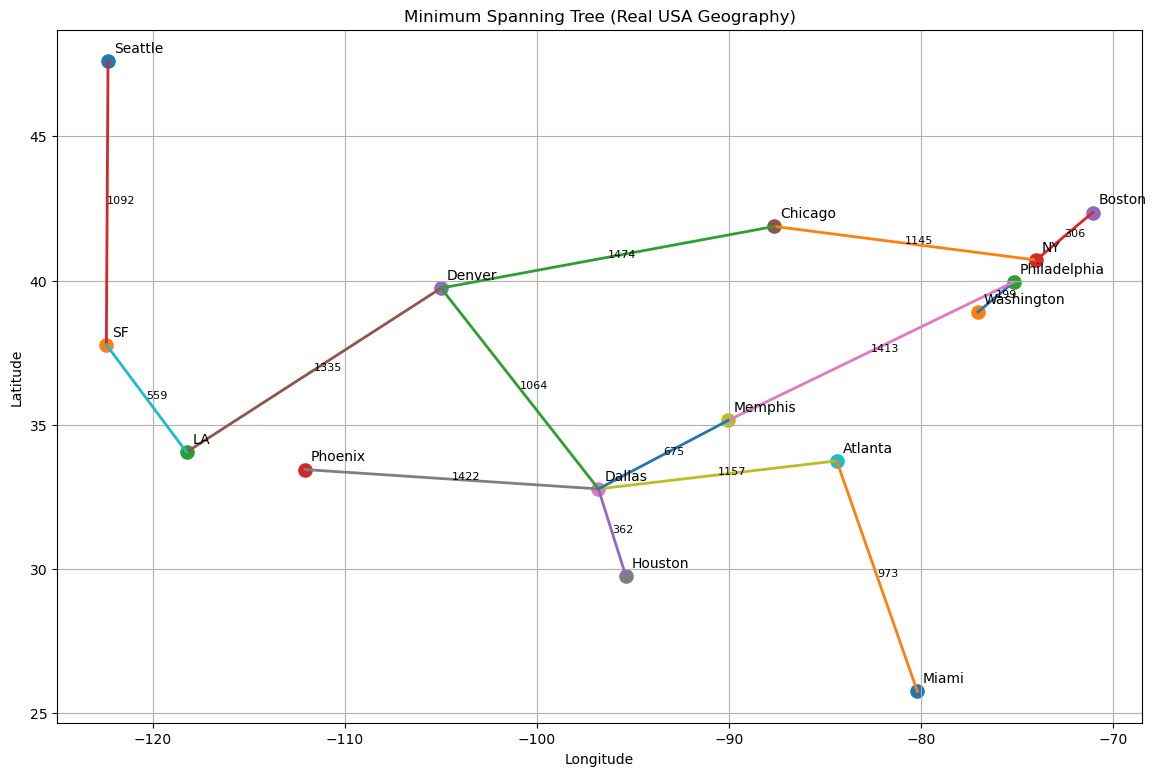

In [41]:
import sys  # Used for INT_MAX (sys.maxsize)
from collections import defaultdict


# ===========================================================
#  Graph class
#  - Stores nodes, directed edges, and weights
#  - Supports both Dijkstra and Prim’s MST
# ===========================================================
class Graph:

  def __init__(self):
    # Set of city names (graph vertices)
    self.nodes = set()

    # Adjacency list:
    #   edges[u] = [v1, v2, ...] meaning directed edges u -> v_i
    self.edges = defaultdict(list)

    # Dictionary for storing weights:
    #   distances[(u, v)] = weight of edge u -> v
    self.distances = {}

  def add_node(self, value):
    """Add a node (city) to the graph."""
    self.nodes.add(value)

  def add_edge(self, from_node, to_node, distance):
    """
    Add a directed edge and its weight.
    Example: add_edge("Denver", "Dallas", 1064)
    """
    self.edges[from_node].append(to_node)
    self.distances[(from_node, to_node)] = distance

  def initializeDistances(self):
    """
    Special helper for MST initialization.
    The assignment's sample MST code expects each node to have a
    default root-distance entry (node, "") = 0.
    We do NOT initialize all (i, j) because this graph is sparse.
    """
    for i in self.nodes:
      self.distances[(i, "")] = 0


# ===========================================================
#  Dijkstra’s Single Source Shortest Path (SSSP)
#  Used for Q2 to compute all shortest paths from Denver
# ===========================================================
def dijkstra_city_distance(graph, s):
  """
  Runs Dijkstra from start city s and prints formatted output such as:

      Distance from Denver to 'Dallas':1064 with path(Denver to Dallas)

  The function:
      - Maintains visited dict (city -> shortest known distance)
      - Maintains path dict (city -> predecessor)
      - Prints final SSSP results in required assignment format
  """

  # visited holds shortest known distances to each city that has been relaxed
  visited = {s: 0}

  # path[v] = predecessor of v in the shortest path
  # start city has no predecessor → store empty string
  path = dict.fromkeys(graph.nodes, "")

  # nodes remaining to process
  nodes = set(graph.nodes)

  while nodes:
    min_node = None

    # Select unprocessed node with smallest distance found so far
    for node in nodes:
      if node in visited:
        if min_node is None:
          min_node = node
        elif visited[node] < visited[min_node]:
          min_node = node

    # If no reachable node remains, stop
    if min_node is None:
      break

    # Remove chosen node from remaining set
    nodes.remove(min_node)
    current_weight = visited[min_node]

    # Build the path string by walking backwards from the node to start
    pathStr = ""
    currentCity = min_node

    # Reconstruct path from predecessors
    while path[currentCity] != "":
      pathStr = " to " + currentCity + pathStr
      currentCity = path[currentCity]
    pathStr = currentCity + pathStr  # prepend start city

    # Print in required assignment output style
    print(
        f"Distance from {s} to '{min_node}':{visited[min_node]} with path({pathStr})"
    )

    # --------------------
    # Relax neighbors
    # --------------------
    for v in graph.edges[min_node]:
      weight = current_weight + graph.distances[(min_node, v)]

      # If v is unvisited OR we found a shorter path, relax it
      if v not in visited or weight < visited[v]:
        visited[v] = weight
        path[v] = min_node  # track parent for path reconstruction

  return visited  # optional return; printing already done


# ===========================================================
#  Prim’s MST
#  Used to compute the Minimum Spanning Tree from Denver (Q2)
# ===========================================================

def printMST(parent, g):
  """
  Utility function to print the MST in the exact assignment format.
  parent[v] = u means edge u -> v is included in MST.
  """
  print("\n\t\tEdge \t\t\t\tWeight\n")
  total = 0

  for i in parent.keys():
    total += g.distances[(i, parent[i])]
    # Root city has parent == ""
    if parent[i] == "":
      print(f"{i:>15} {i:>15} {g.distances[(i, parent[i])]:.>20d}")
    else:
      print(f"{parent[i]:>15} {i:>15} {g.distances[(i, parent[i])]:.>20d}")

  print("\nTotal MST: ", "\t", total)


def minKey(g, key, mstSet):
  """
  Return the city with the smallest key[] value among those NOT yet
  included in the MST. Prints the selected city and cost, following
  the assignment’s output requirement.
  """

  min_val = sys.maxsize
  min_index = None

  # Iterate over all cities in graph
  for city in g.nodes:
    if mstSet[city] is False and key[city] < min_val:
      min_val = key[city]
      min_index = city

  # Print node selection (assignment format: "Dallas is selected. Distance: 1064")
  print(min_index, "is selected. Distance:", min_val)

  return min_index


def primMST(g, start):
  """
  Computes the MST starting from a given city using Prim's algorithm.

  Returns:
      parent: dictionary mapping each city to its MST parent.
  """

  # key[v] = weight of cheapest edge connecting v into MST
  key = {city: sys.maxsize for city in g.nodes}

  # parent[v] = city that connects v into MST
  parent = {city: "" for city in g.nodes}

  # mstSet[v] = True if v is already included into MST
  mstSet = {city: False for city in g.nodes}

  # Start city has key = 0 so it's picked first
  key[start] = 0

  # Add all vertices one-by-one
  for _ in range(len(g.nodes)):

    # Pick city with smallest key[] that is not yet added
    u = minKey(g, key, mstSet)
    mstSet[u] = True

    # Relax edges from u: update MST keys for neighbors
    for v in g.edges[u]:
      w = g.distances[(u, v)]
      # If v is not in MST and edge (u,v) is cheaper than current key[v]
      if mstSet[v] is False and w < key[v]:
        key[v] = w
        parent[v] = u   # Track who v connects to in MST

  # Print MST structure
  printMST(parent, g)
  return parent


# ===========================================================
#  Main program: Build graph, run Dijkstra & Prim MST
# ===========================================================
if __name__ == "__main__":

  g = Graph()

  # -------------------------
  # Add all 15 US cities
  # -------------------------
  g.add_node('Atlanta')
  g.add_node('Boston')
  g.add_node('Chicago')
  g.add_node('Dallas')
  g.add_node('Denver')
  g.add_node('Houston')
  g.add_node('LA')
  g.add_node('Memphis')
  g.add_node('Miami')
  g.add_node('NY')
  g.add_node('Philadelphia')
  g.add_node('Phoenix')
  g.add_node('SF')
  g.add_node('Seattle')
  g.add_node('Washington')

  # Initialize MST root-distances (as required by assignment starter code)
  g.initializeDistances()

  # -----------------------------------------------------------
  # Add ONLY the edges that exist in the assignment's distance table
  # Every add_edge creates a directed edge. For undirected MST behavior,
  # we add both directions (u->v and v->u).
  # -----------------------------------------------------------

  g.add_edge('Seattle', 'SF', 1092)
  g.add_edge('SF', 'Seattle', 1092)
  g.add_edge('Seattle', 'LA', 1544)
  g.add_edge('LA', 'Seattle', 1544)
  g.add_edge('LA', 'SF', 559)
  g.add_edge('SF', 'LA', 559)

  g.add_edge('LA', 'Houston', 2205)
  g.add_edge('Houston', 'LA', 2205)
  g.add_edge('LA', 'Denver', 1335)
  g.add_edge('Denver', 'LA', 1335)
  g.add_edge('LA', 'NY', 3933)
  g.add_edge('NY', 'LA', 3933)
  g.add_edge('LA', 'Miami', 3755)
  g.add_edge('Miami', 'LA', 3755)

  g.add_edge('Denver', 'Dallas', 1064)
  g.add_edge('Dallas', 'Denver', 1064)
  g.add_edge('Denver', 'Boston', 2839)
  g.add_edge('Boston', 'Denver', 2839)
  g.add_edge('Denver', 'Memphis', 1411)
  g.add_edge('Memphis', 'Denver', 1411)
  g.add_edge('Denver', 'Chicago', 1474)
  g.add_edge('Chicago', 'Denver', 1474)

  g.add_edge('Chicago', 'Boston', 1367)
  g.add_edge('Boston', 'Chicago', 1367)
  g.add_edge('Chicago', 'NY', 1145)
  g.add_edge('NY', 'Chicago', 1145)
  g.add_edge('Boston', 'NY', 306)
  g.add_edge('NY', 'Boston', 306)

  g.add_edge('Boston', 'Atlanta', 1505)
  g.add_edge('Atlanta', 'Boston', 1505)
  g.add_edge('Atlanta', 'Dallas', 1157)
  g.add_edge('Dallas', 'Atlanta', 1157)
  g.add_edge('Dallas', 'Houston', 362)
  g.add_edge('Houston', 'Dallas', 362)
  g.add_edge('Atlanta', 'Miami', 973)
  g.add_edge('Miami', 'Atlanta', 973)

  g.add_edge('Atlanta', 'SF', 3434)
  g.add_edge('SF', 'Atlanta', 3434)

  g.add_edge('Dallas', 'Memphis', 675)
  g.add_edge('Memphis', 'Dallas', 675)
  g.add_edge('Memphis', 'Philadelphia', 1413)
  g.add_edge('Philadelphia', 'Memphis', 1413)

  g.add_edge('Miami', 'Phoenix', 3182)
  g.add_edge('Phoenix', 'Miami', 3182)
  g.add_edge('Miami', 'Washington', 1487)
  g.add_edge('Washington', 'Miami', 1487)

  g.add_edge('Phoenix', 'NY', 3441)
  g.add_edge('NY', 'Phoenix', 3441)
  g.add_edge('Phoenix', 'Chicago', 2332)
  g.add_edge('Chicago', 'Phoenix', 2332)
  g.add_edge('Phoenix', 'Dallas', 1422)
  g.add_edge('Dallas', 'Phoenix', 1422)

  g.add_edge('Philadelphia', 'Washington', 199)
  g.add_edge('Washington', 'Philadelphia', 199)
  g.add_edge('Philadelphia', 'Phoenix', 3342)
  g.add_edge('Phoenix', 'Philadelphia', 3342)

  g.add_edge('Washington', 'Dallas', 1900)
  g.add_edge('Dallas', 'Washington', 1900)
  g.add_edge('Washington', 'Denver', 2395)
  g.add_edge('Denver', 'Washington', 2395)


  # -----------------------------------------------------------
  # Run Dijkstra from Denver (Q2 requirement)
  # -----------------------------------------------------------
  print("===== Dijkstra's Shortest Paths from Denver =====")
  dijkstra_city_distance(g, 'Denver')

  # -----------------------------------------------------------
  # Run Prim's MST from Denver (Q2 requirement)
  # -----------------------------------------------------------
  print("\n===== Minimum Spanning Tree (Prim's Algorithm) =====")
  parent = primMST(g, 'Denver')

  # Plot MST using coordinates (function provided separately)
  plot_MST(parent, g)


In [5]:
'''
TinyZip and TinyUnZip
'''

from heapq import heappush, heappop, heapify
from collections import defaultdict
from bitarray import bitarray, decodetree
import math
import os


# 1. Huffman Coding - Build Code Table
def build_huffman(text):
    """
    Build a Huffman code table for the given text.

    Returns:
        huffman_codes: dict mapping char -> bitarray code
        freq:          dict mapping char -> frequency
        huff_cost:     expected Huffman cost in bits
        ascii_cost:    expected ASCII cost in bits
        fcl_cost:      expected optimal Fixed Code Length cost in bits
    """

    # 1) Build frequency table (Dictionary ADT)
    freq = defaultdict(int)
    for ch in text:
        freq[ch] += 1

    if not freq:
        # Empty file case: return empty data structures
        return {}, {}, 0, 0, 0

    # 2) Build Huffman tree using a heap
    # Each heap element: [weight, [symbol, code_string], [symbol, code_string], ...]
    heap = [[weight, [symbol, ""]] for symbol, weight in freq.items()]
    heapify(heap)

    # Edge case: only 1 distinct character in the file
    if len(heap) == 1:
        weight, (symbol, _) = heap[0]
        huffman_codes = {symbol: bitarray("0")}
    else:
        # Build the Huffman tree by combining two smallest subtrees repeatedly
        while len(heap) > 1:
            lo = heappop(heap)  # subtree with smallest weight
            hi = heappop(heap)  # subtree with second smallest weight

            # prepend '0' to the codes in the 'lo' subtree
            for pair in lo[1:]:
                pair[1] = '0' + pair[1]
            # prepend '1' to the codes in the 'hi' subtree
            for pair in hi[1:]:
                pair[1] = '1' + pair[1]

            # push the combined tree back to heap
            heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])

        # heap[0] now contains [total_weight, [symbol, code], [symbol, code], ...]
        huff_list = heappop(heap)[1:]

        # Convert to dict: char -> bitarray
        huffman_codes = {symbol: bitarray(code_str) for symbol, code_str in huff_list}

    # 3) Print the Huffman code table (character, weight, code)
    print("character      Weight            Huffman Code")

    # Sort primarily by descending frequency, secondarily by character
    for ch, w in sorted(freq.items(), key=lambda kv: (-kv[1], kv[0])):
        # Display character nicely, including newline and space
        if ch == ' ':
            display_char = ' '        # space
        elif ch == '\n':
            display_char = "\\n"      # show newline as '\n'
        else:
            display_char = ch

        code_str = huffman_codes[ch].to01()  # convert bitarray to '01010' string
        print(f"{display_char:>10} {w:>10} {code_str:>20}")

    # 4) Compute expected cost of Huffman, ASCII, and FCL

    total_chars = sum(freq.values())

    # Huffman cost: sum(freq[ch] * length_of_code[ch])
    huff_cost = sum(freq[ch] * len(huffman_codes[ch]) for ch in freq)

    # ASCII cost: 8 bits per character
    ascii_cost = total_chars * 8

    # FCL (Fixed Code Length) cost: ceil(log2(#distinct_chars)) bits per char
    distinct_chars = len(freq)
    if distinct_chars > 1:
        fcl_bits = math.ceil(math.log2(distinct_chars))
    else:
        # If only one char, 1 bit is enough
        fcl_bits = 1
    fcl_cost = total_chars * fcl_bits

    print("\nExpected cost of Huffman code cost:", huff_cost)
    print("Expected cost of ASCII cost:", ascii_cost)

    # Efficiency improvement defined as (other_cost / huff_cost - 1) * 100
    # so that the example numbers match (e.g., ~83%)
    if huff_cost > 0:
        eff_ascii = int(round((ascii_cost / huff_cost - 1) * 100))
        eff_fcl = int(round((fcl_cost / huff_cost - 1) * 100))
    else:
        eff_ascii = eff_fcl = 0

    print("Huffman efficiency improvement over ASCII code:", f"{eff_ascii}%")
    print("Expected cost of optimal FCL cost:", fcl_cost)
    print("Huffman efficiency improvement over FCL:", f"{eff_fcl}%")

    return huffman_codes, freq, huff_cost, ascii_cost, fcl_cost


# 2. Tiny Zip (Compression using Huffman)

def tiny_zip(text, file_name, huffman):
    """
    Compress 'text' using Huffman code 'huffman' and write to a binary file.

    Args:
        text      : original text to compress
        file_name : original file name (e.g., "King.txt")
        huffman   : dict char -> bitarray Huffman code

    Returns:
        zip_file_name : name of the created compressed file (e.g., "King.zip")
        zip_bits      : number of bits in the compressed bitstream
        zip_bytes     : number of bytes in the compressed file
    """

    # Derive zip file name: "King.txt" -> "King.zip"
    base, ext = os.path.splitext(file_name)
    zip_file_name = base + ".zip"

    # Convert text to a single bitarray using the Huffman code table
    encoded_bits = bitarray()
    for ch in text:
        encoded_bits.extend(huffman[ch])

    # Number of bits in the compressed representation
    zip_bits = len(encoded_bits)

    # Write the encoded bitarray to a binary file
    with open(zip_file_name, "wb") as f:
        encoded_bits.tofile(f)

    # Get compressed file size in bytes from the OS
    zip_bytes = os.path.getsize(zip_file_name)

    print(f"The size of {zip_file_name}: {zip_bytes}")

    return zip_file_name, zip_bits, zip_bytes



# 3. Tiny Unzip (Decompression using Huffman)

def tiny_unzip(zip_file_name, huffman, zip_size_bits):
    """
    Decompress a Huffman-compressed binary file back to text.

    Args:
        zip_file_name : name of the zipped file (e.g., "King.zip")
        huffman       : dict char -> bitarray Huffman code
        zip_size_bits : the number of valid bits in the compressed bitstream

    Returns:
        out_file_name : name of the unzipped text file (e.g., "King.unzipped.txt")
    """

    # Build a decoding tree from the Huffman code dict
    # decodetree() constructs a fast decoder from symbol -> bitarray mapping
    decode_tree = decodetree(huffman)

    # Read binary data from the zip file into a bitarray
    bit_stream = bitarray()
    with open(zip_file_name, "rb") as f:
        bit_stream.fromfile(f)

    # The last byte may have extra padding bits; slice only the actual valid bits
    bit_stream = bit_stream[:zip_size_bits]

    # Decode the bitarray to the original sequence of characters
    decoded_chars = bit_stream.decode(decode_tree)
    text = "".join(decoded_chars)

    # Output file: "King.zip" -> "King.unzipped.txt"
    base, ext = os.path.splitext(zip_file_name)
    out_file_name = base + ".unzipped.txt"

    # Write the decoded text to the unzipped output file
    with open(out_file_name, "w", encoding="utf-8") as f:
        f.write(text)

    # Size of the unzipped file in bytes
    out_bytes = os.path.getsize(out_file_name)
    print(f"The size of {out_file_name}: {out_bytes}")

    return out_file_name


# 4. main() - Overall TinyZip / TinyUnzip Flow

def main():
    # Ask user for the file name to encode
    file_name = input("Enter a file name to encode:").strip()

    if not os.path.exists(file_name):
        print("File does not exist. Exiting.")
        return

    # Read entire file content as text
    with open(file_name, "r", encoding="utf-8") as f:
        text = f.read()

    # 1) Build Huffman code table and display stats
    huffman, freq, huff_cost, ascii_cost, fcl_cost = build_huffman(text)

    # Original file size in bytes
    orig_size = os.path.getsize(file_name)
    print(f"The size of {file_name} {orig_size}")

    # 2) Tiny Zip: compress using Huffman codes
    zip_file_name, zip_bits, zip_bytes = tiny_zip(text, file_name, huffman)

    # 3) Tiny Unzip: decompress compressed file
    unzipped_file_name = tiny_unzip(zip_file_name, huffman, zip_bits)

if __name__ == "__main__":
    main()


Enter a file name to encode: King.txt


character      Weight            Huffman Code
                 1623                  111
         e        885                  010
         t        656                 1011
         o        604                 1010
         i        542                 1000
         a        539                 0111
         n        450                 0011
         s        419                 0001
         r        413                 0000
         h        385                11011
         l        328                11000
         d        254                01101
         f        220                00101
         m        181               110101
         c        176               110100
         u        175               110011
         g        167               100111
         w        146               100101
         y        124               011001
         b        110               011000
         p         93              1100101
         v         81              1100100
        

In [57]:
'''
Extra Credit Problems: Word Cloud and OBST
Author: Yaseer Sabir

This script demonstrates how to:
1. Query the NewsAPI "everything" endpoint.
2. Retrieve article metadata related to a chosen topic (here: "big data").
3. Print the raw JSON response and extract article titles.
4. Use this data later for generating word clouds and OBST frequency analysis.
'''

import pprint
import requests     

# ------------------------------------------------------------
# My private API key for NewsAPI
# ------------------------------------------------------------
secret = '90e656b29bed46eca4819f56939eecd9'

# ------------------------------------------------------------
# News API endpoint for article search
# ------------------------------------------------------------
url = 'https://newsapi.org/v2/everything?'

# ------------------------------------------------------------
# Query parameters:
#   q         — search term ("big data" in this example)
#   pageSize  — number of articles returned (max allowed = 100)
#   apiKey    — my personal NewsAPI key
#
# ------------------------------------------------------------
parameters = {
    'q': 'big data',   # query phrase
    'pageSize': 20,    # number of articles to retrieve
    'apiKey': secret   # my API key
}

# ------------------------------------------------------------
# Make HTTP GET request to News API
# ------------------------------------------------------------
response = requests.get(url, params=parameters)

# Convert returned JSON payload into Python dict
response_json = response.json()

# Pretty-print the entire JSON structure for inspection
pprint.pprint(response_json)

# ------------------------------------------------------------
# Print only the titles of the retrieved articles
# This is what can be fed into a word-cloud generator
# ------------------------------------------------------------
for article in response_json.get('articles', []):
    print(article['title'])


{'articles': [{'author': 'Molly Taft',
               'content': 'Thomas, who won reelection last week, points to the '
                          'local pushback against the proposed Prince William '
                          'Digital Gateway, which would put more than 30 data '
                          'centers on the edge of a national reserve loc… '
                          '[+1718 chars]',
               'description': 'A new report finds that local opposition to '
                              'data centers skyrocketed in the second quarter '
                              'of this year.',
               'publishedAt': '2025-11-14T16:43:03Z',
               'source': {'id': 'wired', 'name': 'Wired'},
               'title': 'The Data Center Resistance Has Arrived',
               'url': 'https://www.wired.com/story/the-data-center-resistance-has-arrived/',
               'urlToImage': 'https://media.wired.com/photos/6915e464265f0c3818c2b32f/191:100/w_1280,c_limit/111425-%20Local-

In [49]:
# ------------------------------------------------------------
# Combine all article titles into one large text string.
# This aggregated text can later be used for:
#   - word cloud generation
#   - frequency counting
#   - OBST construction using word probabilities
# ------------------------------------------------------------

text_combined = ""

# Loop through each article in the API response
for article in response_json["articles"]:
    # Append the article title followed by a space
    text_combined += article["title"] + " "

# ------------------------------------------------------------
# Display the FIRST 300 characters of the combined text
# This is just a preview to confirm the extraction worked.
# ------------------------------------------------------------
print(text_combined[:300])


The Data Center Resistance Has Arrived Cloudflare Has Blocked 416 Billion AI Bot Requests Since July 1 Polar Loop Review: Better Than a Whoop 5.0? Europe is scaling back its landmark privacy and AI laws OpenAI’s Smackdown by a German Court Hints at What’s Next for AI and Art How X's new location fea


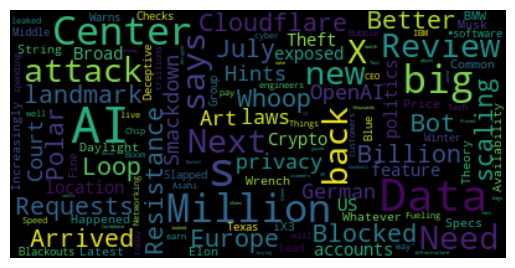

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Generate a word cloud from the combined article title text.
# 'text_combined' contains all titles concatenated into one string.
# WordCloud automatically:
#   - tokenizes words
#   - counts frequencies
#   - sizes words based on frequency
# ------------------------------------------------------------

wordcloud = WordCloud(max_font_size=40).generate(text_combined)

# ------------------------------------------------------------
# Display the word cloud image using matplotlib
# ------------------------------------------------------------
plt.figure()  # create a new figure
plt.imshow(wordcloud, interpolation="bilinear")  # smooth rendering
plt.axis("off")  # hide axes for a cleaner look
plt.show()  # render the word cloud


# 1) Yes

In [53]:
'''
Trying my choice of words

Steps performed in this block:
1. Query NewsAPI for a chosen keyword/phrase ("Professor").
2. Restrict the date range to a specific day (Nov 30, 2025).
3. Retrieve articles that match the query.
4. Print the article titles, which can later be used to:
     - Build a combined text corpus
     - Generate a word cloud
     - Compute word frequencies for OBST
'''

from newsapi import NewsApiClient

# ------------------------------------------------------------
# Initialize the NewsAPI client using your API key
# (IMPORTANT: Do NOT publish your key in public repositories)
# ------------------------------------------------------------
newsapi = NewsApiClient(api_key="90e656b29bed46eca4819f56939eecd9")

# ------------------------------------------------------------
# Query parameters:
#   q             — exact phrase "Professor"
#   from_param    — start of date range
#   to            — end of date range
#   language      — restrict to English-language results
#   sort_by       — order results by relevancy
#
# This retrieves only articles from a *single day*.
# ------------------------------------------------------------
response = newsapi.get_everything(
    q='"Professor"',          # exact phrase search using quotes
    from_param='2025-11-30',  # start date
    to='2025-11-30',          # end date
    language='en',            # English articles only
    sort_by='relevancy',
)

# ------------------------------------------------------------
# Print the title of each returned article.
# These titles will later be used for:
#   - Word cloud generation
#   - Text frequency counting
#   - OBST frequency-based weighting
# --------------------------------------


In [61]:
text_combined = ""

for article in response["articles"]:
    if article["title"]:
        text_combined += article["title"] + " "

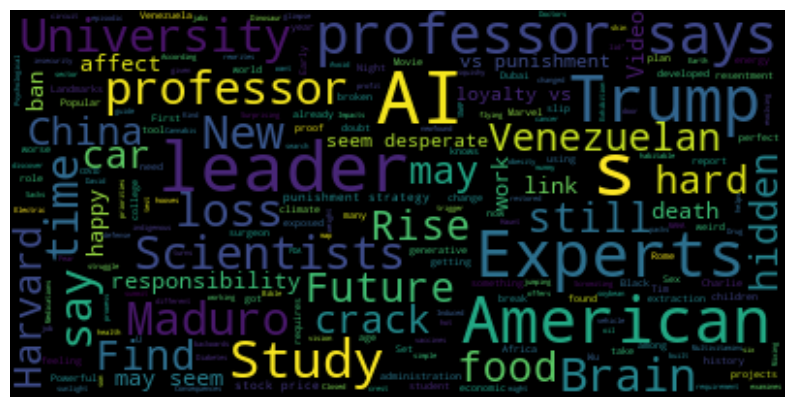

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(max_font_size=40).generate(text_combined)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [55]:
'''
OBST Code
Author: Yaseer Sabir

This script performs the Extra Credit tasks:
1. Extract top words from a word cloud (based on NewsAPI text).
2. Build a RANDOM Binary Search Tree (BST) using those words.
3. Compute its weighted search cost (using word frequencies).
4. Build an Optimal Binary Search Tree (OBST) using Dynamic Programming.
5. Compute the weighted search cost of the OBST.
6. Compare BST vs OBST performance.
'''

import random

# ------------------------------------------------------------
# wordcloud.words_ is a dictionary provided by the WordCloud object.
# It maps:  { word : relative_frequency }
# Example: { 'thanksgiving': 1.0, 'sale': 0.45, ... }
# ------------------------------------------------------------
words_dict = wordcloud.words_

# Select the top N most frequent words
n = 50
top_items = sorted(words_dict.items(), key=lambda kv: kv[1], reverse=True)[:n]

# ------------------------------------------------------------
# Separate word list and frequency table
# ------------------------------------------------------------
words = [w for w, f in top_items]                 # list of words
weights = {w: f for w, f in top_items}            # maps word → frequency

# Normalize frequencies to probabilities (optional but useful)
total = sum(weights.values())
probs = {w: f / total for w, f in weights.items()}


# ============================================================
#  PART 1 — Regular BST
# ============================================================

class BSTNode:
    """Basic Binary Search Tree node (not balanced)."""
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None


def bst_insert(root, key):
    """Insert a key into the BST using standard rules."""
    if root is None:
        return BSTNode(key)
    if key < root.key:
        root.left = bst_insert(root.left, key)
    elif key > root.key:
        root.right = bst_insert(root.right, key)
    # Equal keys are ignored for experiment
    return root


def bst_weighted_cost(root, depth, weight_dict):
    """
    Compute weighted search cost:
        cost = Σ (depth(node) * weight(node))
    Recursively sum over the tree.
    """
    if root is None:
        return 0.0

    cost_here = depth * weight_dict[root.key]

    return (cost_here +
            bst_weighted_cost(root.left, depth + 1, weight_dict) +
            bst_weighted_cost(root.right, depth + 1, weight_dict))


# ------------------------------------------------------------
# Build a random insertion BST
# ------------------------------------------------------------
keys_random = words[:]     # copy word list
random.shuffle(keys_random) # randomize insertion order

bst_root = None
for w in keys_random:
    bst_root = bst_insert(bst_root, w)

# Compute cost
regular_cost = bst_weighted_cost(bst_root, depth=1, weight_dict=weights)

print("Regular BST weighted cost:", regular_cost)


# ============================================================
#  PART 2 — OBST (Dynamic Programming Algorithm)
# ============================================================

def build_obst(keys, p):
    """
    Build Dynamic Programming cost table for the OBST.

    Arguments:
        keys : sorted list of words
        p    : list of weights/probabilities aligned with keys

    Returns:
        e[0][n-1]  — minimal expected search cost
        root_idx   — DP table storing optimal root indices
    """

    n = len(keys)

    # --------------------------------------------------------
    # Prefix sums allow O(1) computation of weight(i,j)
    # weight(i,j) = p[i] + ... + p[j]
    # --------------------------------------------------------
    prefix = [0.0] * (n + 1)
    for i in range(n):
        prefix[i + 1] = prefix[i] + p[i]

    def weight(i, j):
        return prefix[j + 1] - prefix[i]

    # DP tables:
    # e[i][j] = optimal expected cost for keys[i...j]
    # root_idx[i][j] = index r giving optimal root
    e = [[0.0] * n for _ in range(n)]
    root_idx = [[0] * n for _ in range(n)]

    # Base case: subtree size 1
    for i in range(n):
        e[i][i] = p[i]
        root_idx[i][i] = i

    # --------------------------------------------------------
    # Fill tables for all lengths 2..n
    # --------------------------------------------------------
    for length in range(2, n + 1):
        for i in range(0, n - length + 1):
            j = i + length - 1
            e[i][j] = float("inf")
            w = weight(i, j)

            # Try all possible roots r
            for r in range(i, j + 1):
                left = e[i][r - 1] if r > i else 0.0
                right = e[r + 1][j] if r < j else 0.0
                cost = left + right + w

                if cost < e[i][j]:
                    e[i][j] = cost
                    root_idx[i][j] = r

    return e[0][n - 1], root_idx


# ============================================================
#  PART 3 — Rebuild the OBST from root index table
# ============================================================

class OBSTNode:
    """Node class for the reconstructed OBST."""
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None


def build_obst_tree(keys, root_idx, i, j):
    """Recursively reconstruct OBST using DP root table."""
    if i > j:
        return None

    r = root_idx[i][j]
    node = OBSTNode(keys[r])

    node.left = build_obst_tree(keys, root_idx, i, r - 1)
    node.right = build_obst_tree(keys, root_idx, r + 1, j)

    return node


def obst_weighted_cost(root, depth, weight_dict):
    """Compute weighted cost of the OBST exactly like the BST cost function."""
    if root is None:
        return 0.0

    cost_here = depth * weight_dict[root.key]

    return (cost_here +
            obst_weighted_cost(root.left, depth + 1, weight_dict) +
            obst_weighted_cost(root.right, depth + 1, weight_dict))


# ============================================================
#  PART 4 — Run OBST and Compare Results
# ============================================================

# Sort keys alphabetically (required for OBST algorithm)
sorted_keys = sorted(words)
p_list = [weights[w] for w in sorted_keys]

# Run DP algorithm
dp_cost, root_idx = build_obst(sorted_keys, p_list)

# Reconstruct tree
obst_root = build_obst_tree(sorted_keys, root_idx, 0, len(sorted_keys) - 1)

# Compute weighted cost
tree_cost = obst_weighted_cost(obst_root, depth=1, weight_dict=weights)

# ------------------------------------------------------------
# Print comparison
# ------------------------------------------------------------
print("DP cost from table:", dp_cost)
print("OBST tree depth weighted cost:", tree_cost)
print("Regular BST cost:", regular_cost)


Regular BST weighted cost: 94.8
DP cost from table: 66.19999999999996
OBST tree depth weighted cost: 66.2
Regular BST cost: 94.8
